In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv(r'D:\projects\banking-churn-analysis\data\raw\BankChurners.csv')
print('Total columns and rows in the dataset:')
print('-' * 50)
print(f'Rows: {df.shape[0]}, Columns: {df.shape[1]}')
print('\nFirst 5 rows of the dataset:')
print('-' * 50)
display(df.head())
print('Overview of the dataset:')
print('-' * 50)
print(df.info())


In [ ]:
print(df.shape)

df = df.drop(columns=[
    'CLIENTNUM',
    'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1',
    'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2'
])

print(df.shape)

In [ ]:
for col in ['Education_Level', 'Marital_Status', 'Income_Category']:
    print(f"--- {col} ---")
    print(df[col].value_counts())
    print(f"Unknown %: {round(df[col].value_counts(normalize=True).get('Unknown', 0) * 100, 2)}%\n")

In [ ]:
print(df.isnull().sum())
print('\nData Types:')
print(df.dtypes)
print('-' * 50)
print('\nDescriptive Statistics:')
print(df.describe())

df.to_csv('../data/processed/bankchurners_cleaned.csv', index=False)

In [ ]:
print(df['Attrition_Flag'].value_counts())
print(df['Attrition_Flag'].value_counts(normalize=True) * 100)

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Attrition_Flag')
plt.title('Customer Attrition Count')
plt.tight_layout()
plt.savefig('../outputs/charts/class_balance.png', dpi=150, bbox_inches='tight')
plt.show()  

In [ ]:
attrition_by_card = df.groupby('Card_Category')['Attrition_Flag'].apply(
    lambda x: (x == 'Attrited Customer').mean() * 100
).sort_values(ascending=False)

print(attrition_by_card)

plt.figure(figsize=(8,5))
attrition_by_card.plot(kind='barh', color='steelblue')
plt.xlabel('Attrition Rate (%)')
plt.title('Attrition Rate by Card Category')
for i, v in enumerate(attrition_by_card):
    plt.text(v + 0.3, i, f'{v:.2f}%', va='center')
plt.tight_layout()
plt.savefig('../outputs/charts/attrition_by_card_category.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Attrition_Flag', y='Total_Trans_Ct')
plt.title('Transaction Count: Attrited vs Existing Customers')
plt.ylabel('Total Transaction Count')
plt.tight_layout()
plt.savefig('../outputs/charts/boxplot_trans_count.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Attrition_Flag', y='Months_Inactive_12_mon')
plt.title('Months Inactive: Attrited vs Existing Customers')
plt.ylabel('Months Inactive (Last 12 Months)')
plt.tight_layout()
plt.savefig('../outputs/charts/boxplot_months_inactive.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
plt.figure(figsize=(9,6))
colors = {'Attrited Customer': 'red', 'Existing Customer': 'blue'}
for status, color in colors.items():
    subset = df[df['Attrition_Flag'] == status]
    plt.scatter(subset['Total_Trans_Amt'], subset['Total_Trans_Ct'], 
                c=color, label=status, alpha=0.4, s=15)

plt.xlabel('Total Transaction Amount')
plt.ylabel('Total Transaction Count')
plt.title('Transaction Amount vs Count by Attrition Status')
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/charts/scatter_amt_vs_count.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
df['Attrition_Numeric'] = (df['Attrition_Flag'] == 'Attrited Customer').astype(int)

plt.figure(figsize=(12,9))
numeric_df = df.select_dtypes(include=['int64', 'float64'])
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Correlation Heatmap - Numeric Variables')
plt.tight_layout()
plt.savefig('../outputs/charts/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

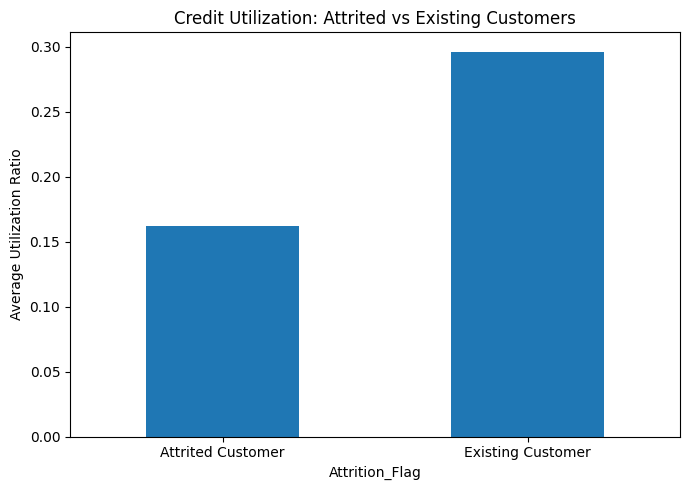

In [20]:
util_comparison = df.groupby('Attrition_Flag')['Avg_Utilization_Ratio'].mean()

plt.figure(figsize=(7,5))
util_comparison.plot(kind='bar')
plt.ylabel('Average Utilization Ratio')
plt.title('Credit Utilization: Attrited vs Existing Customers')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../outputs/charts/utilization_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Key Business Insights & Retention Recommendations

### 1. Customer attrition is a significant retention concern
**Finding:** The bank has already lost a meaningful share of its customer base.  
**Specific number:** 1,627 out of 10,127 customers have attrited, representing an overall attrition rate of **16.07%**.  
**Retention action:** Establish an early-warning retention program to identify customers showing declining engagement before they officially churn.

### 2. Transaction frequency is a strong behavioral indicator of attrition
**Finding:** Attrited customers complete substantially fewer transactions than existing customers.  
**Specific number:** Existing customers average **68.7 transactions**, compared with **44.9 transactions** for attrited customers. `Total_Trans_Ct` also has a **-0.37 correlation** with attrition.  
**Retention action:** Flag customers whose transaction frequency is declining and trigger targeted engagement campaigns, personalized card offers, or usage incentives before activity falls further.

### 3. Attrition risk rises sharply once customers reach 3 or more bank contacts
**Finding:** Customer attrition increases meaningfully when the number of bank contacts rises from 2 to 3, suggesting repeated service interactions may indicate unresolved issues or dissatisfaction.  
**Specific number:** Attrition increases from **12.49% at 2 contacts to 20.15% at 3 contacts**, and reaches **33.52% at 5 contacts**. Customers with 6 contacts show **100% attrition**, although this group contains only 54 customers.  
**Retention action:** Escalate customers at **3+ contacts within 12 months** to a dedicated retention or service-resolution team so recurring issues can be investigated before further churn risk develops.

### 4. Platinum customers show the highest observed attrition rate, but the result is based on a small sample
**Finding:** Platinum cardholders have the highest observed attrition rate among card categories; however, the estimate should be interpreted cautiously because the category has very few customers.  
**Specific number:** Platinum customers have a **25.00% attrition rate**, but the category contains only **20 customers (n=20)**.  
**Retention action:** Conduct individual account reviews for Platinum customers rather than immediately launching a broad Platinum retention campaign. More data should be collected before concluding that Platinum card membership itself is associated with higher churn.

### 5. Attrited customers show substantially lower credit utilization
**Finding:** Customers who churned used a smaller proportion of their available credit than existing customers, indicating lower card engagement among attrited customers.  
**Specific number:** Attrited customers have an average utilization ratio of **0.162**, compared with **0.296** for existing customers. `Avg_Utilization_Ratio` has a **-0.18 correlation** with attrition, as shown in the correlation heatmap.  
**Retention action:** Identify customers with persistently low or declining credit utilization and target them with personalized spending rewards, category-based cashback, or card-usage incentives to rebuild engagement.